### 이미지 예측 (YOLO 모델)

In [ ]:
# 사전 설치 라이브러리 : pip install ultralytics opencv-python  ==> 여기서 ultralytics는 YOLOv8 모델을 다운로드 사용
# pip 최신 버전 업그레이드 : python -m pip install --upgrade pip
# 라이브러리 설치 에러시 가상 환경 확인 및 실행 : .\.venv\Scripts\activate
import cv2   # OpenCV로 이미지 처리(예: 색상 변환, 바운딩 박스 그리기)
import matplotlib.pyplot as plt
from ultralytics import YOLO   # YOLOv8 모델을 로드하고 예측에 사용
import requests  # 인터넷에서 이미지를 다운로드
from io import BytesIO   # 다운로드한 이미지 데이터를 바이트(이진)코드로 저장 후 메모리에서 처리
from PIL import Image
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# 폰트지정
# plt.rcParams['font.family'] = 'Malgun Gothic'

In [ ]:
# YOLOv8 모델 로드
# yolov8n.pt는 가장 가벼운 모델로 CPU 환경에 적합
model = YOLO('yolov8n.pt')

In [ ]:
# 테스트 이미지 URL
# image_url = "https://www.fitpetmall.com/wp-content/uploads/2023/10/shutterstock_1844153299-1024x683-1.png"  # 고양이 샘플
image_url = "https://image.lawtimes.co.kr/images/202707.jpg" # 강아지 샘플

# URL에서 이미지 다운로드
try:
    response = requests.get(image_url)  # 이미지 데이터 다운로드
    image_data = BytesIO(response.content) # 바이트코드 변환
    # PIL(Pillow)로 이미지 열기
    image_pil = Image.open(image_data)
    # numpy array로 변환 (OpenCV 형식)
    image_np = np.array(image_pil)
    # OpenCV는 BGR 형식을 사용하므로 RGB에서 BGR로 변환
    image_cv = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

except Exception as e:
    print(f"이미지 다운로드 또는 변환 중 오류 발생: {e}")
    exit()

# 이미지 크기 확인
print(f"이미지 크기: {image_cv.shape}")   # 이미지의 크기(높이, 너비, 채널 수)

이미지 크기: (400, 600, 3)


In [ ]:
# 원본 이미지 복사 (시각화 작업을 위해, 원본보존)
image_for_display = image_cv.copy()

# 모델 예측 실행
results = model.predict(source=image_cv, save=False, verbose=False)

# 탐지된 객체 정보 저장
best_object = None

# 탐지 결과에서 'cat' 또는 'dog' 중 가장 높은 신뢰도의 객체 찾기
if results and results[0].boxes:
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # boxes.xyxy: 바운딩 박스 좌표(왼쪽 상단: x1, y1, 오른쪽 하단: x2, y2)
        classes = result.boxes.cls.cpu().numpy() # 탐지된 객체의 클래스 ID(예: 15는 고양이, 16은 강아지)
        confidences = result.boxes.conf.cpu().numpy()  # 탐지 신뢰도(0~1 사이 값)
        class_names = result.names   # 클래스 ID에 대응하는 이름(예: 15: 'cat', 16: 'dog')

        for box, cls, conf in zip(boxes, classes, confidences):
            class_name = class_names[int(cls)]

            # 'cat'과 'dog'만 필터링
            if class_name in ['cat', 'dog']:
                if best_object is None or conf > best_object['confidence']:
                    best_object = {
                        'class_name': class_name,
                        'confidence': conf,
                        'box': box
                    }

# 탐지된 객체 시각화
best_guess = "탐지된 객체 없음"
if best_object:
    class_name = best_object['class_name']
    confidence = best_object['confidence']
    box = best_object['box']

    # 최고 신뢰도 객체 정보 출력
    x1, y1, x2, y2 = [int(v) for v in box]
    print(f"\n--- 최고 신뢰도 탐지 결과 ---")
    print(f"클래스: {class_name}, 신뢰도: {confidence:.2f}, 좌표: ({x1}, {y1}, {x2}, {y2})")

    # 라벨 그리기
    label = f'{class_name}: {confidence:.2f}'

    # 바운딩 박스 그리기
    cv2.rectangle(image_for_display, (x1, y1), (x2, y2), (0, 255, 0), 2)  # 녹색(0, 255, 0), 두께(2) 사각형

    # 텍스트 라벨과 배경 박스 그리기
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
    cv2.rectangle(image_for_display, (x1, y1 - h - baseline), (x1 + w, y1), (0, 255, 0), -1)   # 라벨 배경 사각형, -1: 사각형을 채움
    cv2.putText(image_for_display, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)

    best_guess = class_name


--- 최고 신뢰도 탐지 결과 ---
클래스: dog, 신뢰도: 0.68, 좌표: (252, 63, 598, 238)


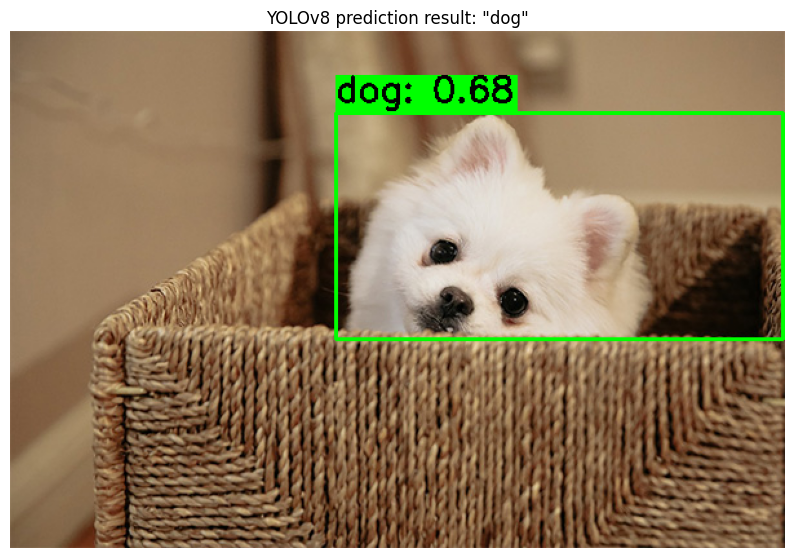

In [ ]:
# 결과 이미지를 BGR에서 RGB로 변환하여 Matplotlib로 출력
image_result_rgb = cv2.cvtColor(image_for_display, cv2.COLOR_BGR2RGB)

# 이미지 출력
plt.figure(figsize=(10, 8))
plt.imshow(image_result_rgb)
plt.axis('off')
plt.title(f'YOLOv8 prediction result: "{best_guess}"')
plt.show()